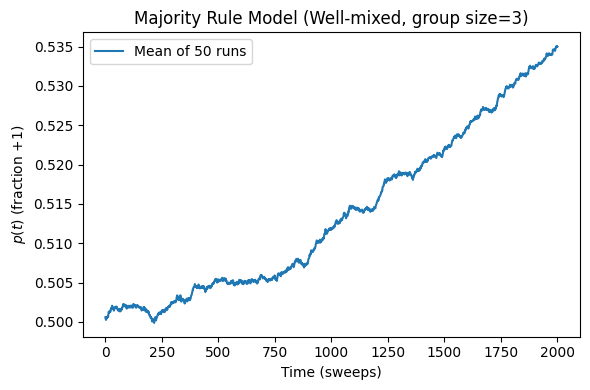

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def majority_rule_once(N=1000, sweeps=2000, rng=None):
    """
    Majority Rule Model (well-mixed, group size=3).
    Returns p(t) over time (fraction of +1 opinion).
    """
    if rng is None:
        rng = np.random.default_rng()
    
    spins = rng.choice([-1, 1], size=N)
    p_values = [np.mean(spins == 1)]
    
    for sweep in range(sweeps):
        # pick 3 distinct agents
        group = rng.choice(N, size=3, replace=False)
        majority_opinion = np.sign(np.sum(spins[group]))
        
        # update all three to majority
        spins[group] = majority_opinion if majority_opinion != 0 else rng.choice([-1, 1])
        
        p_values.append(np.mean(spins == 1))
        
        # stop if consensus reached
        if abs(np.sum(spins)) == N:
            break
    
    return np.array(p_values)

# --- parameters ---
N = 1000
runs = 50
steps = 2000
rng = np.random.default_rng(42)

# --- run multiple simulations ---
time_max = steps
p_mat = np.zeros((runs, time_max+1))

for r in range(runs):
    p_series = majority_rule_once(N=N, sweeps=time_max, rng=rng)
    p_mat[r, :len(p_series)] = p_series
    p_mat[r, len(p_series):] = p_series[-1]  # fill after consensus

p_mean = p_mat.mean(axis=0)

# --- plot ---
plt.figure(figsize=(6,4))
plt.plot(p_mean, label=f'Mean of {runs} runs')
plt.xlabel('Time (sweeps)')
plt.ylabel(r'$p(t)$ (fraction +1)')
plt.title('Majority Rule Model (Well-mixed, group size=3)')
plt.legend()
plt.tight_layout()
plt.show()


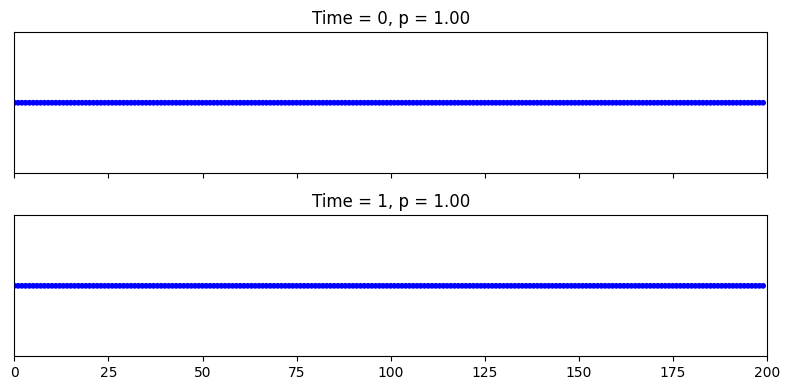

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def majority_rule_with_snaps(N=200, sweeps=500, p0=0.5, snap_times=(0, 50, 100, 200, 300, 400, 500), rng=None):
    if rng is None:
        rng = np.random.default_rng()
    
    # initial spins with chosen p0
    spins = rng.choice([-1, 1], size=N, p=[1-p0, p0])
    
    snapshots = {0: spins.copy()}
    
    for sweep in range(1, sweeps+1):
        group = rng.choice(N, size=3, replace=False)
        majority_opinion = np.sign(np.sum(spins[group]))
        spins[group] = majority_opinion if majority_opinion != 0 else rng.choice([-1, 1])
        
        if sweep in snap_times:
            snapshots[sweep] = spins.copy()
        
        if abs(np.sum(spins)) == N:  # consensus
            snapshots[sweep] = spins.copy()
            break
    
    return snapshots

# Run
rng = np.random.default_rng(42)
snapshots = majority_rule_with_snaps(N=200, p0=1, sweeps=500)

# Plot time-lapse
times = sorted(snapshots.keys())
fig, axes = plt.subplots(len(times), 1, figsize=(8, 2*len(times)), sharex=True)

for ax, t in zip(axes, times):
    spins = snapshots[t]
    colors = ['blue' if s==1 else 'red' for s in spins]
    ax.scatter(range(len(spins)), [0]*len(spins), c=colors, s=10)
    ax.set_title(f'Time = {t}, p = {np.mean(spins==1):.2f}')
    ax.set_yticks([])
    ax.set_xlim(0, len(spins))
    
plt.tight_layout()
plt.show()


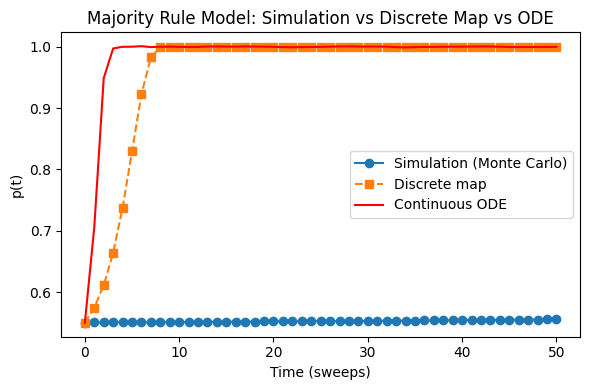

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ---------------- Majority Rule Simulation ----------------
def majority_rule_simulation(N=1000, p0=0.55, sweeps=50, runs=50, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    p_traj = np.zeros((runs, sweeps+1))
    
    for r in range(runs):
        spins = rng.choice([-1,1], size=N, p=[1-p0, p0])
        p_traj[r,0] = np.mean(spins==1)
        
        for t in range(1, sweeps+1):
            group = rng.choice(N, size=3, replace=False)
            majority = np.sign(np.sum(spins[group]))
            spins[group] = majority if majority != 0 else rng.choice([-1, 1])
            p_traj[r,t] = np.mean(spins==1)
    
    return np.mean(p_traj, axis=0)

# ---------------- Discrete Map ----------------
def discrete_map(p0=0.55, sweeps=50):
    p_values = [p0]
    for _ in range(sweeps):
        p = p_values[-1]
        p_next = 3*p**2 - 2*p**3
        p_values.append(p_next)
    return np.array(p_values)

# ---------------- Continuous ODE ----------------
def dp_dt(t, p):
    return 3*p*(1-p)*(2*p-1)

def continuous_ode(p0=0.55, sweeps=50):
    sol = solve_ivp(dp_dt, [0, sweeps], [p0], t_eval=np.linspace(0, sweeps, sweeps+1))
    return sol.t, sol.y[0]

# ---------------- Run everything ----------------
rng = np.random.default_rng(42)
p0 = 0.55
steps = 50

# Simulation
sim_p = majority_rule_simulation(N=1000, p0=p0, sweeps=steps, runs=200, rng=rng)

# Discrete map
map_p = discrete_map(p0=p0, sweeps=steps)

# Continuous ODE
t_ode, ode_p = continuous_ode(p0=p0, sweeps=steps)

# ---------------- Plot ----------------
plt.figure(figsize=(6,4))
plt.plot(sim_p, 'o-', label='Simulation (Monte Carlo)')
plt.plot(map_p, 's--', label='Discrete map')
plt.plot(t_ode, ode_p, 'r-', label='Continuous ODE')
plt.xlabel('Time (sweeps)')
plt.ylabel('p(t)')
plt.title('Majority Rule Model: Simulation vs Discrete Map vs ODE')
plt.legend()
plt.tight_layout()
plt.show()


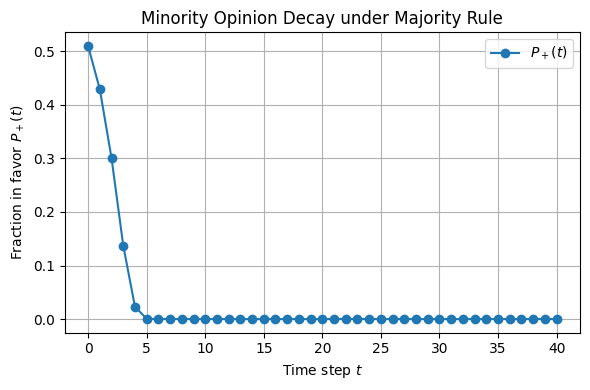

In [3]:
# Re-import required libraries due to code execution environment reset
import numpy as np
import matplotlib.pyplot as plt
import math
# Parameters
a = {1: 0.0, 2: 0.0, 3: 0.3, 4: 0.3, 5: 0.2, 6: 0.2}  # Group size distribution from the paper
L = max(a.keys())
timesteps = 40
P_vals = []

# Initial fraction in favor of reform
P = 0.51
P_vals.append(P)

# Iterative update of P based on majority rule within groups
for t in range(timesteps):
    P_new = 0
    for k, ak in a.items():
        prob = 0
        for j in range((k // 2) + 1, k + 1):
            prob += (
                math.comb(k, j) * (P**j) * ((1 - P) ** (k - j))
            )
        P_new += ak * prob
    P = P_new
    P_vals.append(P)

# Plotting the evolution of majority opinion
plt.figure(figsize=(6, 4))
plt.plot(range(timesteps + 1), P_vals, 'o-', label='$P_+(t)$')
plt.xlabel('Time step $t$')
plt.ylabel('Fraction in favor $P_+(t)$')
plt.title('Minority Opinion Decay under Majority Rule')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


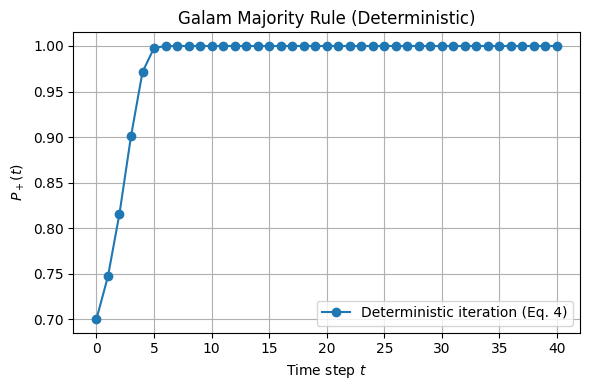

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Group size distribution from paper (example values)
a = {3: 0.3, 4: 0.3, 5: 0.2, 6: 0.2}
timesteps = 40
P_values = []

# Initial fraction
P = 0.70
P_values.append(P)

# Iterate Eq. (4)
for t in range(timesteps):
    P_new = 0
    for k, ak in a.items():
        prob = 0
        for j in range((k // 2) + 1, k + 1):
            prob += math.comb(k, j) * (P**j) * ((1 - P) ** (k - j))
        P_new += ak * prob
    P = P_new
    P_values.append(P)

# Plot deterministic iteration
plt.figure(figsize=(6,4))
plt.plot(P_values, 'o-', label='Deterministic iteration (Eq. 4)')
plt.xlabel('Time step $t$')
plt.ylabel('$P_+(t)$')
plt.title('Galam Majority Rule (Deterministic)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


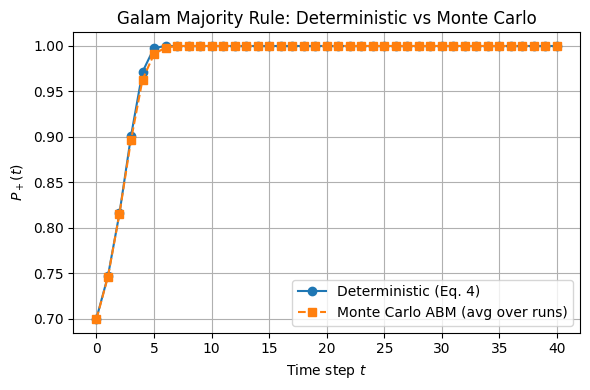

In [24]:
def galam_monte_carlo(N=1000, p0=0.70, a={3:0.3,4:0.3,5:0.2,6:0.2}, sweeps=40, runs=50):
    rng = np.random.default_rng()
    p_traj = np.zeros((runs, sweeps+1))
    
    for r in range(runs):
        # Initial opinions: +1 = yes, -1 = no
        spins = rng.choice([1, -1], size=N, p=[p0, 1-p0])
        p_traj[r,0] = np.mean(spins==1)
        
        for t in range(1, sweeps+1):
            new_spins = spins.copy()
            # Random grouping of population
            indices = rng.permutation(N)
            pos = 0
            while pos < N:
                # Choose group size
                k = rng.choice(list(a.keys()), p=list(a.values()))
                group = indices[pos:pos+k]
                if len(group) < k:
                    break
                # Majority vote in group
                group_sum = np.sum(spins[group])
                if group_sum > 0:   # Majority yes
                    new_spins[group] = 1
                elif group_sum < 0: # Majority no
                    new_spins[group] = -1
                else:               # Tie defaults to no
                    new_spins[group] = -1
                pos += k
            spins = new_spins
            p_traj[r,t] = np.mean(spins==1)
    
    return np.mean(p_traj, axis=0)

# Run Monte Carlo
P_mc = galam_monte_carlo()

# Compare deterministic vs Monte Carlo
plt.figure(figsize=(6,4))
plt.plot(P_values, 'o-', label='Deterministic (Eq. 4)')
plt.plot(P_mc, 's--', label='Monte Carlo ABM (avg over runs)')
plt.xlabel('Time step $t$')
plt.ylabel('$P_+(t)$')
plt.title('Galam Majority Rule: Deterministic vs Monte Carlo')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


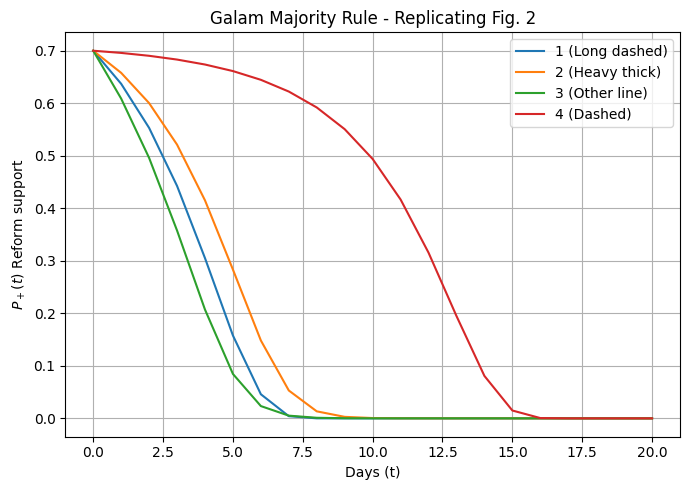

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Define simulation parameters from the figure description
timesteps = 20
P0 = 0.70

# Group size distributions for each curve
a_distributions = {
    "1 (Long dashed)": {2: 0.5, 3: 0.5},
    "2 (Heavy thick)": {1: 0.2, 2: 0.3, 3: 0.2, 4: 0.2, 5: 0.1},
    "3 (Other line)": {1: 0.2, 2: 0.2, 3: 0.2, 4: 0.2, 5: 0.1},
    "4 (Dashed)": {2: 0.3, 3: 0.7}
}

def galam_iteration(a, P_init=P0, steps=timesteps):
    P_vals = [P_init]
    P = P_init
    for _ in range(steps):
        P_new = 0
        for k, ak in a.items():
            prob = 0
            for j in range((k // 2) + 1, k + 1):
                prob += math.comb(k, j) * (P**j) * ((1 - P)**(k - j))
            P_new += ak * prob
        P = P_new
        P_vals.append(P)
    return P_vals

# Simulate each case
plt.figure(figsize=(7, 5))
for label, a_dist in a_distributions.items():
    P_curve = galam_iteration(a_dist)
    plt.plot(range(len(P_curve)), P_curve, label=label)

plt.xlabel("Days (t)")
plt.ylabel("$P_+(t)$ Reform support")
plt.title("Galam Majority Rule - Replicating Fig. 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


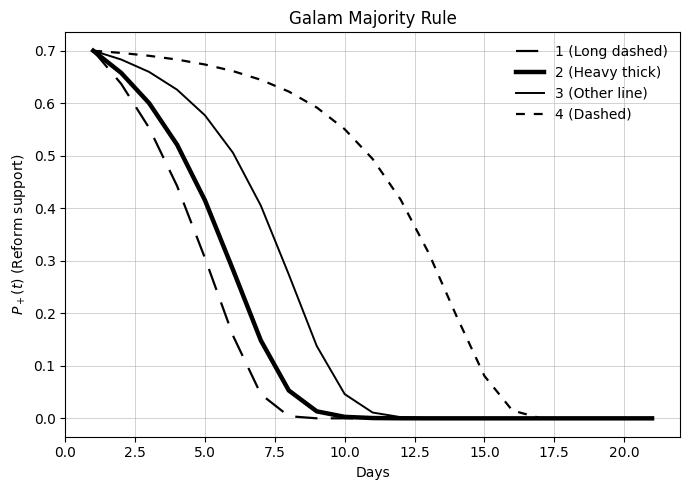

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Parameters
steps = 20
P1 = 0.70   # paper: P_+(1) = 0.70
L = 6

# Group-size distributions (fill missing sizes with 0)
a_distributions = {
    "1 (Long dashed)": {2: 0.5, 3: 0.5},
    "2 (Heavy thick)": {1: 0.2, 2: 0.3, 3: 0.2, 4: 0.2, 5: 0.1, 6: 0.0},
    "3 (Other line)":  {1: 0.2, 2: 0.2, 3: 0.2, 4: 0.2, 5: 0.1, 6: 0.1},  # FIXED
    "4 (Dashed)":      {1: 0.0, 2: 0.3, 3: 0.7, 4: 0.0, 5: 0.0, 6: 0.0},
}


def normalize_a(a, tol=1e-12):
    s = sum(a.values())
    if abs(s - 1.0) > tol:
        a = {k: v / s for k, v in a.items()}  # safe renormalization
    return a

def majority_prob_plus(p, k, tie_to_plus=0.0):
    """
    Probability a group of size k ends with '+' under majority rule.
    tie_to_plus = 0  -> tie goes to '-'
    tie_to_plus = 0.5 -> random tie-break
    """
    prob = 0.0

    # strict majority part
    for j in range(k // 2 + 1, k + 1):
        prob += math.comb(k, j) * (p**j) * ((1 - p)**(k - j))

    # tie part (only for even k)
    if k % 2 == 0 and tie_to_plus > 0:
        j = k // 2
        prob += tie_to_plus * math.comb(k, j) * (p**j) * ((1 - p)**(k - j))

    return prob

def galam_iteration(a, P_init=P1, steps=steps, tie_to_plus=0.0):
    a = normalize_a(a)
    P_vals = [P_init]
    P = P_init
    for _ in range(steps):
        P_new = 0.0
        for k, ak in a.items():
            P_new += ak * majority_prob_plus(P, k, tie_to_plus=tie_to_plus)
        P = P_new
        P_vals.append(P)
    return np.array(P_vals)

# Black & white styles (distinct line types)
styles = {
    "1 (Long dashed)": dict(color="black", linewidth=1.6, linestyle=(0, (10, 6))),
    "2 (Heavy thick)": dict(color="black", linewidth=3.2, linestyle="-"),
    "3 (Other line)":  dict(color="black", linewidth=1.4, linestyle="-"),
    "4 (Dashed)":      dict(color="black", linewidth=1.6, linestyle=(0, (4, 4))),
}

plt.figure(figsize=(7, 5))

days = np.arange(1, steps + 2)  # so first point is day 1 (matches caption)
for label, a_dist in a_distributions.items():
    P_curve = galam_iteration(a_dist, tie_to_plus=0.0)  # tie -> '-' as in the paper
    plt.plot(days, P_curve, label=label, **styles[label])

plt.xlabel("Days")
plt.ylabel(r"$P_+(t)$ (Reform support)")
plt.title("Galam Majority Rule")
plt.legend(frameon=False)
plt.grid(True, linewidth=0.4)
plt.tight_layout()
plt.savefig("galam.png", dpi=1000, bbox_inches="tight")
plt.show()

# Optional: save a crisp vector version for printing
# plt.savefig("fig2_reproduction_bw.pdf")


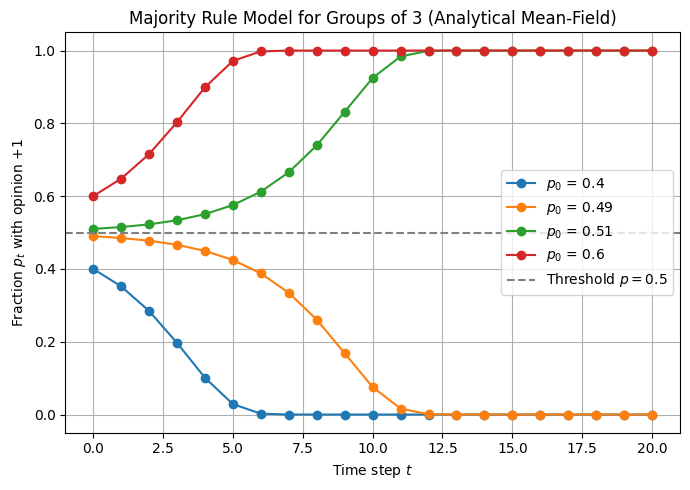

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
timesteps = 20
p0_values = [0.4, 0.49, 0.51, 0.6]  # initial fractions for examples

def majority_rule_k3(p0, steps=timesteps):
    """Mean-field iteration for group size k=3"""
    p_vals = [p0]
    p = p0
    for _ in range(steps):
        p = 3 * p**2 - 2 * p**3
        p_vals.append(p)
    return p_vals

# Plot dynamics for different initial conditions
plt.figure(figsize=(7, 5))
for p0 in p0_values:
    curve = majority_rule_k3(p0)
    plt.plot(range(len(curve)), curve, marker='o', label=f"$p_0$ = {p0}")

plt.axhline(0.5, color='gray', linestyle='--', label="Threshold $p=0.5$")
plt.xlabel("Time step $t$")
plt.ylabel("Fraction $p_t$ with opinion $+1$")
plt.title("Majority Rule Model for Groups of 3 (Analytical Mean-Field)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


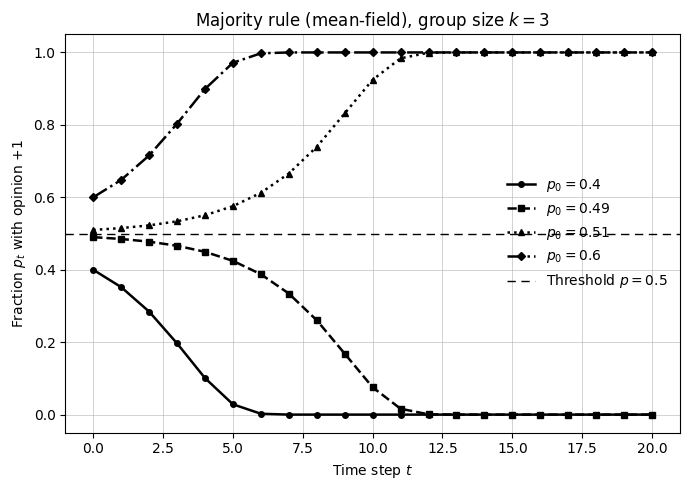

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
timesteps = 20
p0_values = [0.4, 0.49, 0.51, 0.6]

def majority_rule_k3(p0, steps=timesteps):
    """Mean-field iteration for group size k=3."""
    p_vals = [p0]
    p = p0
    for _ in range(steps):
        p = 3 * p**2 - 2 * p**3
        p_vals.append(p)
    return np.array(p_vals)

# B/W styles (all black, different dashes + markers)
styles = [
    dict(color="black", linestyle="-",  marker="o", linewidth=1.8, markersize=4),
    dict(color="black", linestyle="--", marker="s", linewidth=1.8, markersize=4),
    dict(color="black", linestyle=":",  marker="^", linewidth=1.8, markersize=4),
    dict(color="black", linestyle="-.", marker="D", linewidth=1.8, markersize=4),
]

plt.figure(figsize=(7, 5))

t = np.arange(timesteps + 1)
for (p0, st) in zip(p0_values, styles):
    curve = majority_rule_k3(p0)
    plt.plot(t, curve, label=fr"$p_0={p0}$", **st)

# Threshold line (still black, lighter thickness + dashed)
plt.axhline(0.5, color="black", linestyle=(0, (6, 4)), linewidth=1.0, label=r"Threshold $p=0.5$")

plt.xlabel(r"Time step $t$")
plt.ylabel(r"Fraction $p_t$ with opinion $+1$")
plt.title(r"Majority rule (mean-field), group size $k=3$")
plt.legend(frameon=False)
plt.grid(True, linewidth=0.4)
plt.tight_layout()

# Optional: save a vector PDF for crisp printing
plt.savefig("majority_k3_bw.png" , dpi=800)

plt.show()


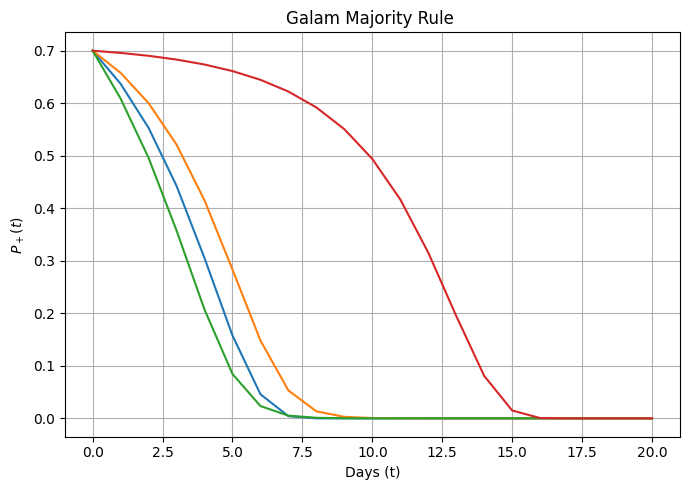

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Simulation parameters
timesteps = 20
P0 = 0.70

# Group size distributions
a_distributions = [
    {2: 0.5, 3: 0.5},  # Case 1
    {1: 0.2, 2: 0.3, 3: 0.2, 4: 0.2, 5: 0.1},  # Case 2
    {1: 0.2, 2: 0.2, 3: 0.2, 4: 0.2, 5: 0.1},  # Case 3
    {2: 0.3, 3: 0.7}   # Case 4
]

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

def galam_iteration(a, P_init=P0, steps=timesteps):
    P_vals = [P_init]
    P = P_init
    for _ in range(steps):
        P_new = 0
        for k, ak in a.items():
            prob = 0
            for j in range((k // 2) + 1, k + 1):
                prob += math.comb(k, j) * (P**j) * ((1 - P)**(k - j))
            P_new += ak * prob
        P = P_new
        P_vals.append(P)
    return P_vals

# Plot results
plt.figure(figsize=(7, 5))
for idx, a_dist in enumerate(a_distributions):
    P_curve = galam_iteration(a_dist)
    plt.plot(range(len(P_curve)), P_curve, color=colors[idx])

plt.xlabel("Days (t)")
plt.ylabel("$P_+(t)$ ")
plt.title("Galam Majority Rule ")
plt.grid(True)
plt.tight_layout()
plt.show()


ABM 

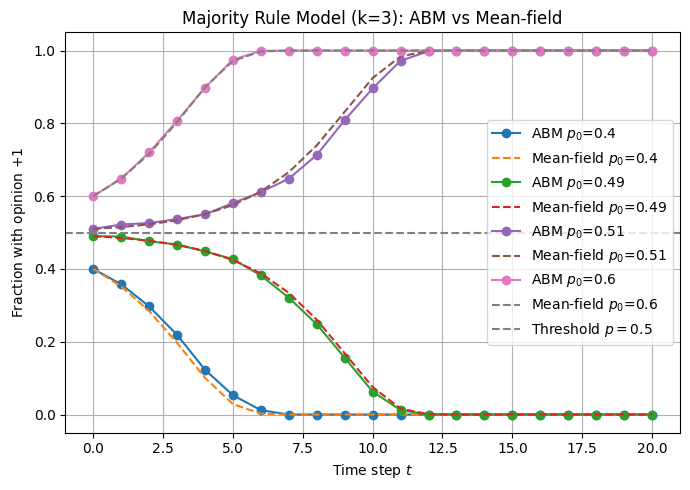

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 3000          # number of agents (should be divisible by 3 for perfect triplets)
timesteps = 20
p0_values = [0.4, 0.49, 0.51, 0.6]  # initial fractions

def majority_rule_abm(p0, steps=timesteps, N=N, seed=None):
    if seed is not None:
        np.random.seed(seed)
    # 1 = +1 opinion, 0 = -1 opinion
    agents = np.zeros(N, dtype=int)
    num_pos = int(p0 * N)
    agents[:num_pos] = 1
    np.random.shuffle(agents)
    
    p_vals = [p0]
    for _ in range(steps):
        np.random.shuffle(agents)
        for i in range(0, N, 3):
            group = agents[i:i+3]
            if np.sum(group) >= 2:   # majority +1
                agents[i:i+3] = 1
            else:                    # majority -1
                agents[i:i+3] = 0
        p_vals.append(np.mean(agents))
    return p_vals

# Run and plot
plt.figure(figsize=(7, 5))
for p0 in p0_values:
    abm_curve = majority_rule_abm(p0, seed=42)
    mf_curve = [p0]
    p = p0
    for _ in range(timesteps):
        p = 3*p**2 - 2*p**3
        mf_curve.append(p)
    plt.plot(range(len(abm_curve)), abm_curve, 'o-', label=f"ABM $p_0$={p0}")
    plt.plot(range(len(mf_curve)), mf_curve, '--', label=f"Mean-field $p_0$={p0}")

plt.axhline(0.5, color='gray', linestyle='--', label="Threshold $p=0.5$")
plt.xlabel("Time step $t$")
plt.ylabel("Fraction with opinion $+1$")
plt.title("Majority Rule Model (k=3): ABM vs Mean-field")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


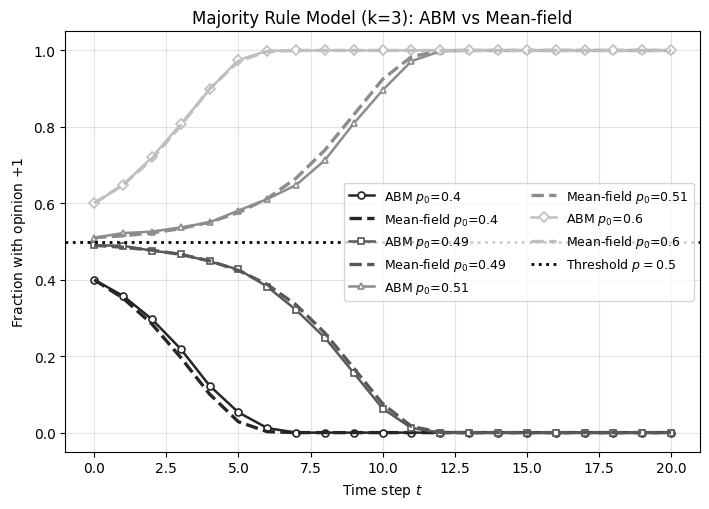

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 3000
timesteps = 20
p0_values = [0.4, 0.49, 0.51, 0.6]

def majority_rule_abm(p0, steps=timesteps, N=N, seed=None):
    if seed is not None:
        np.random.seed(seed)
    agents = np.zeros(N, dtype=int)
    num_pos = int(p0 * N)
    agents[:num_pos] = 1
    np.random.shuffle(agents)

    p_vals = [p0]
    for _ in range(steps):
        np.random.shuffle(agents)
        for i in range(0, N, 3):
            group = agents[i:i+3]
            agents[i:i+3] = 1 if np.sum(group) >= 2 else 0
        p_vals.append(np.mean(agents))
    return p_vals

def majority_rule_meanfield(p0, steps=timesteps):
    p_vals = [p0]
    p = p0
    for _ in range(steps):
        p = 3*p**2 - 2*p**3
        p_vals.append(p)
    return p_vals

# ---- B/W friendly styles ----
markers = ['o', 's', '^', 'D']  # circle, square, triangle, diamond
gray_levels = ['0.15', '0.35', '0.55', '0.75']  # dark -> light grays (strings work in matplotlib)

plt.figure(figsize=(7.2, 5.2))

for (p0, mk, g) in zip(p0_values, markers, gray_levels):
    abm_curve = majority_rule_abm(p0, seed=42)
    mf_curve  = majority_rule_meanfield(p0)

    t = range(len(abm_curve))

    # ABM: solid + marker (high legibility in B/W)
    plt.plot(
        t, abm_curve,
        linestyle='-',
        marker=mk,
        markersize=5,
        markerfacecolor='white',   # hollow markers print well
        markeredgewidth=1.2,
        linewidth=1.8,
        color=g,
        label=f"ABM $p_0$={p0}"
    )

    # Mean-field: dashed, thicker, same gray (ties pair visually)
    plt.plot(
        t, mf_curve,
        linestyle='--',
        linewidth=2.4,
        color=g,
        label=f"Mean-field $p_0$={p0}"
    )

# Threshold line: dotted + black
plt.axhline(0.5, color='0.0', linestyle=':', linewidth=2.0, label="Threshold $p=0.5$")

plt.xlabel("Time step $t$")
plt.ylabel("Fraction with opinion $+1$")
plt.title("Majority Rule Model (k=3): ABM vs Mean-field")

plt.grid(True, alpha=0.35)
plt.legend(ncol=2, fontsize=9, frameon=True)
plt.tight_layout()
plt.show()


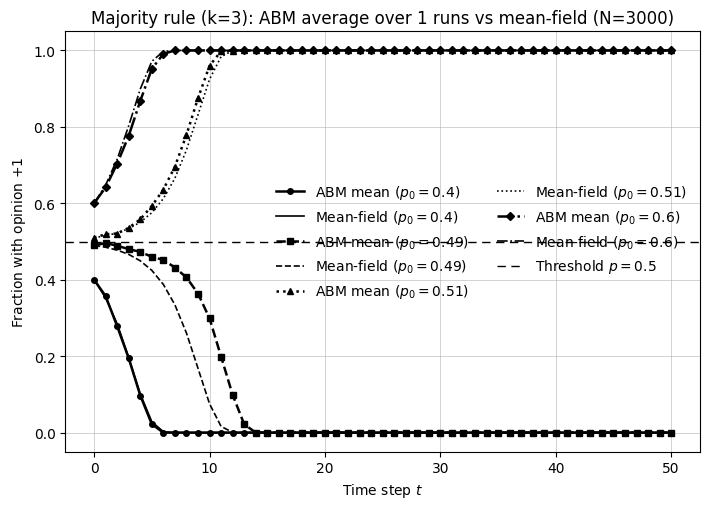

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# User parameters
# ----------------------------
N = 3000
timesteps = 50
p0_values = [0.4, 0.49, 0.51, 0.6]
runs = 1         # number of ABM realizations to average
seed0 = 1         # base seed (changes deterministically across runs)

# ----------------------------
# Model functions
# ----------------------------
def majority_rule_abm_once(p0, steps, N, rng):
    """
    One ABM realization:
    - opinions are 0/1
    - each step: random shuffle, split into triplets, synchronous majority update
    Returns p_t array of length steps+1
    """
    if N % 3 != 0:
        raise ValueError("N must be divisible by 3 for perfect triplets.")

    agents = np.zeros(N, dtype=np.int8)
    num_pos = int(round(p0 * N))
    agents[:num_pos] = 1
    rng.shuffle(agents)

    p_vals = np.empty(steps + 1, dtype=float)
    p_vals[0] = agents.mean()

    for t in range(1, steps + 1):
        rng.shuffle(agents)

        # Update each triplet
        for i in range(0, N, 3):
            s = agents[i] + agents[i + 1] + agents[i + 2]
            agents[i:i + 3] = 1 if s >= 2 else 0

        p_vals[t] = agents.mean()

    return p_vals

def majority_rule_abm_avg(p0, steps, N, runs, seed0):
    """
    Run ABM 'runs' times and return mean and SEM over time.
    """
    all_runs = np.empty((runs, steps + 1), dtype=float)
    for r in range(runs):
        rng = np.random.default_rng(seed0 + r)  # independent-ish streams
        all_runs[r, :] = majority_rule_abm_once(p0, steps, N, rng)

    mean = all_runs.mean(axis=0)
    std = all_runs.std(axis=0, ddof=1)
    sem = std / np.sqrt(runs)
    return mean, sem

def majority_rule_mf(p0, steps):
    """
    Mean-field map for group size k=3:
    p_{t+1} = 3 p_t^2 - 2 p_t^3
    """
    p = p0
    out = np.empty(steps + 1, dtype=float)
    out[0] = p
    for t in range(1, steps + 1):
        p = 3 * p**2 - 2 * p**3
        out[t] = p
    return out

# ----------------------------
# Plotting (black & white friendly)
# ----------------------------
bw_styles = [
    dict(linestyle='-',  marker='o', linewidth=1.8, markersize=4),
    dict(linestyle='--', marker='s', linewidth=1.8, markersize=4),
    dict(linestyle=':',  marker='^', linewidth=1.8, markersize=4),
    dict(linestyle='-.', marker='D', linewidth=1.8, markersize=4),
]

t = np.arange(timesteps + 1)

plt.figure(figsize=(7.2, 5.2))

for idx, p0 in enumerate(p0_values):
    st = bw_styles[idx % len(bw_styles)]

    abm_mean, abm_sem = majority_rule_abm_avg(p0, timesteps, N, runs, seed0 + 1000*idx)
    mf_curve = majority_rule_mf(p0, timesteps)

    # ABM mean curve (black)
    plt.plot(t, abm_mean, color='black', label=fr"ABM mean ($p_0={p0}$)", **st)

    # ABM uncertainty (SEM) as black error bars (print-friendly)
    # show error bars every 2 steps to avoid clutter
    eb_idx = np.arange(0, timesteps + 1, 2)
    plt.errorbar(
        t[eb_idx], abm_mean[eb_idx], yerr=abm_sem[eb_idx],
        fmt='none', ecolor='black', elinewidth=0.9, capsize=2
    )

    # Mean-field curve (black, same linestyle but no markers, slightly thinner)
    plt.plot(t, mf_curve, color='black', linestyle=st['linestyle'], linewidth=1.2,
             label=fr"Mean-field ($p_0={p0}$)")

plt.axhline(0.5, color='black', linestyle=(0, (6, 4)), linewidth=1.0, label=r"Threshold $p=0.5$")

plt.xlabel(r"Time step $t$")
plt.ylabel(r"Fraction with opinion $+1$")
plt.title(fr"Majority rule (k=3): ABM average over {runs} runs vs mean-field (N={N})")
plt.grid(True, linewidth=0.4)
plt.legend(frameon=False, ncol=2)
plt.tight_layout()

# Optional: save a crisp vector file for printing
# plt.savefig("majority_k3_abm_avg_bw.pdf")

plt.show()


p0=0.49: P(fixate at 1)=0.100, mean consensus time=13.20 steps
p0=0.51: P(fixate at 1)=0.940, mean consensus time=13.20 steps


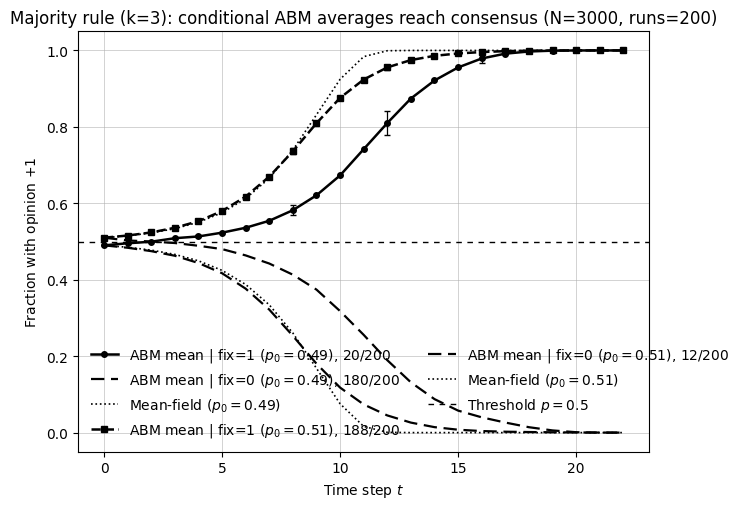

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Parameters
# ----------------------------
N = 3000
p0_values = [0.49, 0.51]   
runs = 200
max_steps = 200            
seed0 = 12345


def abm_until_consensus(p0, N, max_steps, rng):

    if N % 3 != 0:
        raise ValueError("N must be divisible by 3.")

    agents = np.zeros(N, dtype=np.int8)
    num_pos = int(round(p0 * N))
    agents[:num_pos] = 1
    rng.shuffle(agents)

    traj = [agents.mean()]

    for t in range(1, max_steps + 1):
        if agents.sum() == 0:
            return np.array(traj), t - 1, 0
        if agents.sum() == N:
            return np.array(traj), t - 1, 1

        rng.shuffle(agents)

        for i in range(0, N, 3):
            s = agents[i] + agents[i + 1] + agents[i + 2]
            agents[i:i + 3] = 1 if s >= 2 else 0

        traj.append(agents.mean())

    final_state = 1 if agents.mean() >= 0.5 else 0
    return np.array(traj), max_steps, final_state



def many_runs(p0, N, runs, max_steps, seed0):
    trajectories = []
    T_list = []
    finals = []

    for r in range(runs):
        rng = np.random.default_rng(seed0 + r)
        traj, T, final_state = abm_until_consensus(p0, N, max_steps, rng)
        trajectories.append(traj)
        T_list.append(T)
        finals.append(final_state)

    return trajectories, np.array(T_list), np.array(finals)


def pad_trajectories(trajs, finals, T_common=None):
    """
    Pad trajectories to same length by extending with absorbing value (0 or 1).
    If T_common is None: use max length among trajectories.
    """
    if T_common is None:
        T_common = max(len(tr) for tr in trajs) - 1  # steps

    padded = np.empty((len(trajs), T_common + 1), dtype=float)
    for i, tr in enumerate(trajs):
        L = len(tr)
        padded[i, :L] = tr
        # After run ends, stick at consensus
        pad_value = float(finals[i])
        if L < T_common + 1:
            padded[i, L:] = pad_value
    return padded


def mean_and_sem(arr2d):
    mean = arr2d.mean(axis=0)
    std = arr2d.std(axis=0, ddof=1)
    sem = std / np.sqrt(arr2d.shape[0])
    return mean, sem


# ----------------------------
# Mean-field curve (deterministic)
# ----------------------------
def majority_rule_mf(p0, steps):
    p = p0
    out = [p]
    for _ in range(steps):
        p = 3*p**2 - 2*p**3
        out.append(p)
    return np.array(out)


# ----------------------------
# Plot (black & white friendly)
# ----------------------------
plt.figure(figsize=(7.4, 5.2))

styles = [
    dict(color="black", linestyle="-",  marker="o", linewidth=1.8, markersize=4),
    dict(color="black", linestyle="--", marker="s", linewidth=1.8, markersize=4),
    dict(color="black", linestyle=":",  marker="^", linewidth=1.8, markersize=4),
    dict(color="black", linestyle="-.", marker="D", linewidth=1.8, markersize=4),
]

for idx, p0 in enumerate(p0_values):
    trajs, T_list, finals = many_runs(p0, N, runs, max_steps, seed0 + 1000*idx)

    # Pad all runs so each run is absorbing after it reaches consensus
    padded = pad_trajectories(trajs, finals)

    # Unconditional mean (may plateau between 0 and 1 if both outcomes happen)
    mean_all, sem_all = mean_and_sem(padded)

    # Conditional means (these WILL end at 0 or 1)
    mask1 = finals == 1
    mask0 = finals == 0

    # Some p0 might almost always go one way; guard empty masks
    if mask1.any():
        mean_1, sem_1 = mean_and_sem(padded[mask1])
    else:
        mean_1 = sem_1 = None

    if mask0.any():
        mean_0, sem_0 = mean_and_sem(padded[mask0])
    else:
        mean_0 = sem_0 = None

    t = np.arange(padded.shape[1])

    st = styles[idx % len(styles)]

    # Plot conditional mean to + consensus (recommended if you want "reaches consensus")
    if mean_1 is not None:
        plt.plot(t, mean_1, **st, label=fr"ABM mean | fix=1 ($p_0={p0}$), {mask1.sum()}/{runs}")
        eb = np.arange(0, len(t), 4)
        plt.errorbar(t[eb], mean_1[eb], yerr=sem_1[eb], fmt="none", ecolor="black",
                     elinewidth=0.9, capsize=2)

    # Plot conditional mean to 0 with a different dash pattern but still black
    if mean_0 is not None:
        st0 = dict(st)
        st0["linestyle"] = (0, (6, 3))  # custom dash for the 0-consensus conditional
        st0["marker"] = None
        plt.plot(t, mean_0, color="black", linewidth=1.6, linestyle=st0["linestyle"],
                 label=fr"ABM mean | fix=0 ($p_0={p0}$), {mask0.sum()}/{runs}")

    # Plot mean-field for comparison (same p0), thin dotted
    mf = majority_rule_mf(p0, steps=len(t)-1)
    plt.plot(t, mf, color="black", linewidth=1.2, linestyle=":", label=fr"Mean-field ($p_0={p0}$)")

    # Print fixation probability info
    p_fix1 = mask1.mean()
    print(f"p0={p0}: P(fixate at 1)={p_fix1:.3f}, mean consensus time={T_list.mean():.2f} steps")

plt.axhline(0.5, color="black", linestyle=(0, (4, 4)), linewidth=1.0, label=r"Threshold $p=0.5$")
plt.xlabel(r"Time step $t$")
plt.ylabel(r"Fraction with opinion $+1$")
plt.title(fr"Majority rule (k=3): conditional ABM averages reach consensus (N={N}, runs={runs})")
plt.grid(True, linewidth=0.4)
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()


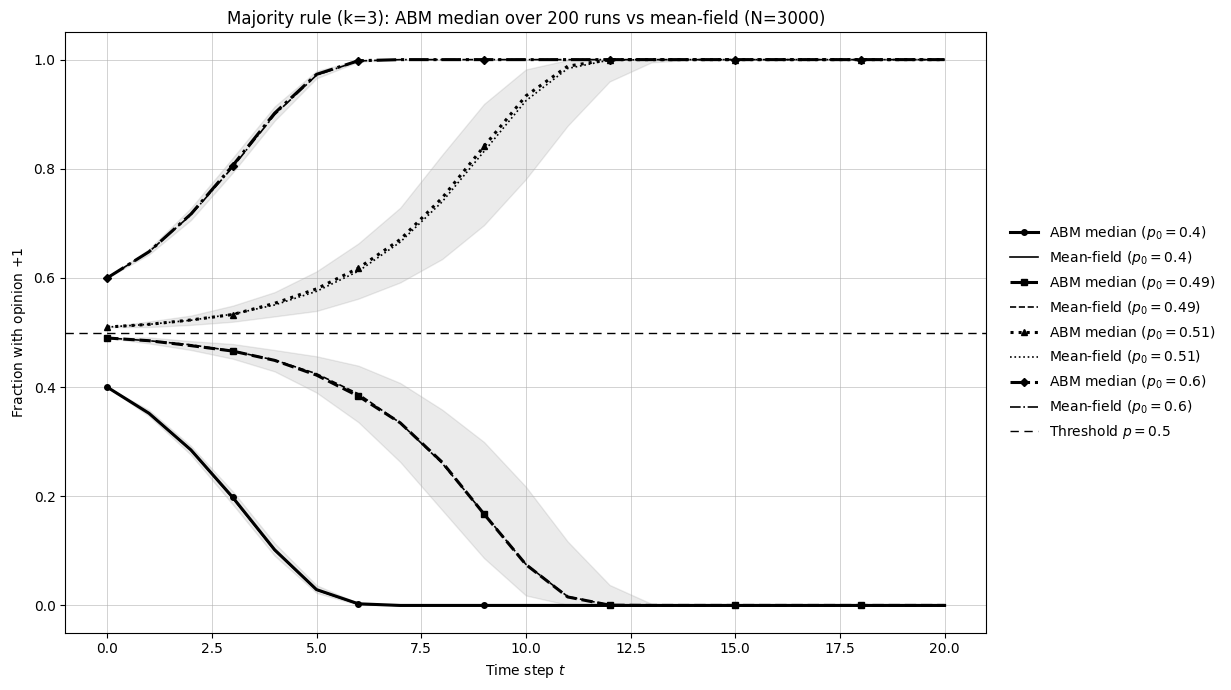

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Parameters
# ----------------------------
N = 3000
timesteps = 20          # plot horizon (we'll pad after consensus)
p0_values = [0.4, 0.49, 0.51, 0.6]
runs = 200
seed0 = 12345

# ----------------------------
# ABM: one run, random triplets, stop at consensus
# ----------------------------
def abm_until_consensus(p0, N, max_steps, rng):
    if N % 3 != 0:
        raise ValueError("N must be divisible by 3 for triplets.")

    agents = np.zeros(N, dtype=np.int8)
    num_pos = int(round(p0 * N))
    agents[:num_pos] = 1
    rng.shuffle(agents)

    traj = [agents.mean()]

    for t in range(1, max_steps + 1):
        s = agents.sum()
        if s == 0:
            return np.array(traj), t - 1, 0
        if s == N:
            return np.array(traj), t - 1, 1

        rng.shuffle(agents)

        for i in range(0, N, 3):
            gsum = agents[i] + agents[i + 1] + agents[i + 2]
            agents[i:i + 3] = 1 if gsum >= 2 else 0

        traj.append(agents.mean())

    # If no consensus by max_steps (rare for k=3), classify by majority
    final_state = 1 if agents.mean() >= 0.5 else 0
    return np.array(traj), max_steps, final_state


def run_many(p0, N, runs, max_steps, seed_base):
    trajs, Ts, finals = [], [], []
    for r in range(runs):
        rng = np.random.default_rng(seed_base + r)
        tr, T, fin = abm_until_consensus(p0, N, max_steps, rng)
        trajs.append(tr)
        Ts.append(T)
        finals.append(fin)
    return trajs, np.array(Ts), np.array(finals)


def pad_trajectories(trajs, finals, T_common):
    """
    Pad each trajectory to length T_common+1 by extending with absorbing value (0 or 1).
    """
    padded = np.empty((len(trajs), T_common + 1), dtype=float)
    for i, tr in enumerate(trajs):
        L = len(tr)
        padded[i, :L] = tr
        if L < T_common + 1:
            padded[i, L:] = float(finals[i])
    return padded


def mean_sem(arr2d):
    mean = arr2d.mean(axis=0)
    std = arr2d.std(axis=0, ddof=1)
    sem = std / np.sqrt(arr2d.shape[0])
    return mean, sem


def median_iqr(arr2d):
    med = np.median(arr2d, axis=0)
    q25 = np.percentile(arr2d, 25, axis=0)
    q75 = np.percentile(arr2d, 75, axis=0)
    return med, q25, q75


def mf_k3(p0, steps):
    p = p0
    out = [p]
    for _ in range(steps):
        p = 3*p**2 - 2*p**3
        out.append(p)
    return np.array(out)

# ----------------------------
# Plotting: B/W friendly + legend outside
# ----------------------------
plt.figure(figsize=(16, 7))  # wider to make room for legend outside
t = np.arange(timesteps + 1)

# Different line styles & markers for each p0
styles = [
    dict(linestyle='-',  marker='o'),
    dict(linestyle='--', marker='s'),
    dict(linestyle=':',  marker='^'),
    dict(linestyle='-.', marker='D'),
]

for idx, p0 in enumerate(p0_values):
    st = styles[idx % len(styles)]

    trajs, Ts, finals = run_many(p0, N, runs, max_steps=timesteps, seed_base=seed0 + 1000*idx)
    padded = pad_trajectories(trajs, finals, T_common=timesteps)

    # ABM stats (unconditional)
    m, se = mean_sem(padded)
    med, q25, q75 = median_iqr(padded)

    # Mean-field
    mf = mf_k3(p0, timesteps)

    # --- Median curve (this is the one that tends to hit 0/1) ---
    plt.plot(
        t, med,
        color='black', linewidth=2.2,
        markersize=4, markevery=3,
        label=fr"ABM median ($p_0={p0}$)",
        **st
    )

    # Optional: IQR band (still print-friendly). Comment out if you want cleaner.
    plt.fill_between(t, q25, q75, color='black', alpha=0.08)

    # --- Mean-field (thin, same linestyle, no markers) ---
    plt.plot(
        t, mf,
        color='black', linewidth=1.2, linestyle=st['linestyle'],
        label=fr"Mean-field ($p_0={p0}$)"
    )

    # If you also want the ABM mean ± SEM, uncomment:
    # plt.plot(t, m, color='black', linewidth=1.5, linestyle=st['linestyle'],
    #          label=fr"ABM mean ($p_0={p0}$)")
    # eb = np.arange(0, timesteps+1, 5)
    # plt.errorbar(t[eb], m[eb], yerr=se[eb], fmt='none',
    #              ecolor='black', elinewidth=0.9, capsize=2)

# Threshold line
plt.axhline(0.5, color='black', linestyle=(0, (6, 4)), linewidth=1.0, label=r"Threshold $p=0.5$")

plt.xlabel(r"Time step $t$")
plt.ylabel(r"Fraction with opinion $+1$")
plt.title(fr"Majority rule (k=3): ABM median over {runs} runs vs mean-field (N={N})")
plt.grid(True, linewidth=0.4)

# Legend outside (right side)
plt.legend(
    frameon=False,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    ncol=1
)

plt.tight_layout(rect=[0, 0, 0.78, 1])  # leave room on the right for legend
# Optional: save vector for printing
plt.savefig("majorityabmvsanalysis.png",dpi=800)
plt.show()
